In [16]:
from Betts_cluster import *
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def get_rect_k_path(nx, ny):
    k_path = []
    
    k_x = [ 2*x/nx for x in range(int(nx/2)+1) ]
    for kx in k_x:
        k_path.append( np.array( [kx, 0] ) )
        
    k_y = [ 2*y/ny for y in range(1, int(ny/2)+1) ]
    
    for ky in k_y:
        k_path.append( np.array( [1, ky] ) )
        
    if nx == ny:
        for ky in (k_y[:-1]).__reversed__():
            k_path.append( np.array( [ky, ky] ) )
    
    return k_path

def get_cluster_k_path(key):
    clust = Cluster(key=key)
    _, k_path = clust.get_k_space()
    return k_path

In [18]:
supercells = [
    '4x4', '18A', '6x4', '24A'
]

k_paths = {}

for sc in supercells:
    if sc.__contains__('x'):
        k_paths[sc] = get_rect_k_path(int(sc[0]), int(sc[-1]))
    else:
        k_paths[sc] = get_cluster_k_path(sc)

In [19]:
def get_progress_along_path(k_point):
    kx, ky = k_point
    
    if ky == 0:
        return kx
    elif kx == 1.:
        return ky + 1
    elif kx == ky:
        return 2 + np.sqrt(2) * (1. - kx)

In [20]:
def plot_points_from_key_and_vars(key : str, dir = '+-', delta = 1., lamb = 1., eta = 1., to_diameter = True, marker_size = 30., c='gray', alpha = .5, ylim=6):
    try:
        p_s = np.loadtxt(fr'data/d={delta}_l={lamb}_e={eta}/{key}_S_{dir}_mag.txt')
        p_x = np.loadtxt(fr'data/d={delta}_l={lamb}_e={eta}/{key}_S_{dir}_en.txt')
    except:
        if eta == 1.:
            p_s = np.loadtxt(fr'data/d={delta}_l={lamb}/{key}_S_{dir}_mag.txt')
            p_x = np.loadtxt(fr'data/d={delta}_l={lamb}/{key}_S_{dir}_en.txt')
        else:
            raise FileNotFoundError
    
    sizes = np.zeros( ( p_s.shape[0], p_s.shape[1] + 1 ) )
    sizes[:, :-1] = p_s
    sizes[:, -1] = p_s[:, 0]
    
    energy = np.zeros( ( p_x.shape[0], p_x.shape[1] + 1 ) )
    energy[:, :-1] = p_x
    energy[:, -1] = p_x[:, 0]
    
    sizes = sizes*marker_size
    
    k_points = np.array(k_paths[key].copy())
    k_path = np.zeros((k_points.shape[0] + 1, k_points.shape[1]))
    k_path[-1, :] = np.array([0, 0])
    k_path[:-1, :] = k_points
    
    if to_diameter:
        sizes = sizes**2
    
    from fractions import Fraction
    
    # ---- Step 1: Build cumulative "distance" along the path ----
    dist = [] #[0.0]
        
    #for i in range(1, len(k_points)):
    #    dk = np.linalg.norm(np.array(k_points[i]) - np.array(k_points[i-1]))
    #    
    #    dist.append(dist[-1] + dk)
    
    for k in k_path[:-1, :]:
        dist.append(get_progress_along_path(k))
    dist.append(2+np.sqrt(2))
    dist = np.array(dist)

    # ---- Helper function to format fractions of π ----
    def format_pi_fraction(value):
        frac = Fraction(value).limit_denominator(12)  # limit denominator (adjust if needed)
        if frac == 0:
            return "0"
        elif frac == 1:
            return r"$\pi$"
        else:
            return fr"$\frac{{{frac.numerator}}}{{{frac.denominator}}}\pi$"

    # ---- Step 2: Define special labels for high symmetry points ----
    labels = []
    tick_positions = []

    for d, (kx, ky) in zip(dist, k_points):
        if (kx, ky) == (0.0, 0.0):
            labels.append(r'$\Gamma$')
        elif (kx, ky) == (1.0, 0.0):
            labels.append(r"$X$")
        elif (kx, ky) == (1.0, 1.0):
            labels.append(r"$M$")
        else:
            kx_label = format_pi_fraction(kx)
            ky_label = format_pi_fraction(ky)
            labels.append(rf"({kx_label}, {ky_label})")
        tick_positions.append(d)
        
    #for ik, k in enumerate(k_points):
    #    for ii in range(sizes.shape[0]):
    #        if sizes[ii, ik] > 0:
    #            plt.scatter( dist[ik], energy[ii, ik], sizes[ii, ik], c=c, alpha=.5)
    
    for ii in range(sizes.shape[0]):
        plt.scatter( dist[:], energy[ii, :], sizes[ii, :], c=c, alpha=alpha)
        
    plt.ylim([0, ylim])
    
    return np.min(energy)

In [21]:
def plot_LSW(delta):
    x_range = np.arange( 0, 2.00001, 0.001 )
    
    gamma_k = ( np.cos(np.pi * np.clip(x_range, 0., 1.)) + np.cos(np.pi * (np.clip(x_range, 1., 2.)-1.)) )/2
    y = 2. * np.sqrt(delta**2 - np.square(gamma_k))
    
    plt.plot( x_range, y, 'black', lw = 1. )
    
    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k_range = np.linspace(1., 0., len(x_range), endpoint=True)
    
    gamma_k = np.cos(np.pi * k_range)
    y = 2. * np.sqrt(delta**2 - np.square(gamma_k))

    plt.plot( x_range, y, 'black', lw = 1. )

def plot_JW_fermions(delta):
    x_range = np.arange( 0, 2.00001, 0.001 )
    
    kx = np.pi * np.clip(x_range, 0., 1.)
    ky = np.pi * (np.clip(x_range, 1., 2.)-1.)
    
    delta_k = ( np.sin(kx)**2 + np.sin(ky)**2 )/4
    y = 2. * np.sqrt(delta**2 + delta_k)
    
    plt.plot( x_range, y, 'black', lw = 1. )
    
    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k_range = np.linspace(1., 0., len(x_range), endpoint=True)
    
    delta_k = np.sin(np.pi * k_range) / 2
    y = 2. * np.sqrt(delta**2 + np.square(delta_k))

    plt.plot( x_range, y, 'black', lw = 1. )


In [22]:
colors = {
    '4x4': '#d81159', '18A': '#8f2d56', '6x4': '#218380', '24A' : '#73d2de'
}

from matplotlib.lines import Line2D

def plot_all_for_var(dir : str = '+-', delta : float = 1., lamb : float = 1., eta = 1., to_diameter : bool = True, marker_size : float = 30., alpha = .5, ylim=6, show = True):

    keys = colors.keys()
    color = colors.values()
    
    min_en = 999.
    
    legend_elements = []
    
    for key, c in zip(keys, color):
        try:
            new_min_en = plot_points_from_key_and_vars(key, dir, delta, lamb, eta, to_diameter, marker_size, c, alpha, ylim)
            if new_min_en < min_en:
                min_en = new_min_en
            legend_elements.append(Line2D([0], [0], marker='o', color='w', label=key,markerfacecolor=c, markersize=10, alpha=alpha))
        except:
            print('No file for key: ' + key)
            
    
    if lamb == 1. and ((delta > 1 and dir == '+-') or delta == 1.) and eta == 1.:
        plot_LSW(delta)
        legend_elements.append(Line2D([0], [0], color='black', lw=1., ls='-', label='LSW'))
    elif delta >= 1 and eta == 0. and dir == '+-':
        plot_JW_fermions(delta)
        legend_elements.append(Line2D([0], [0], color='black', lw=1., ls='-', label='JW-fermions'))
    
    plt.xticks([0, 1., 2., 2.+np.sqrt(2)], [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$'], rotation = 0)
    plt.title(rf'$S^{{{dir}}}(q, \omega)$, '
        + rf'$\Delta$ = {delta}'
        + (rf', $\lambda$ = {lamb}' if (delta != 0) else '')
        + (rf', $\eta$ = {eta}' if (delta != 0) else '')
        )
    plt.ylabel(r'$\omega$/J')
    plt.legend(handles = legend_elements, loc=1)
    if show:
        plt.show()

No file for key: 18A
No file for key: 24A


(0.0, 4.0)

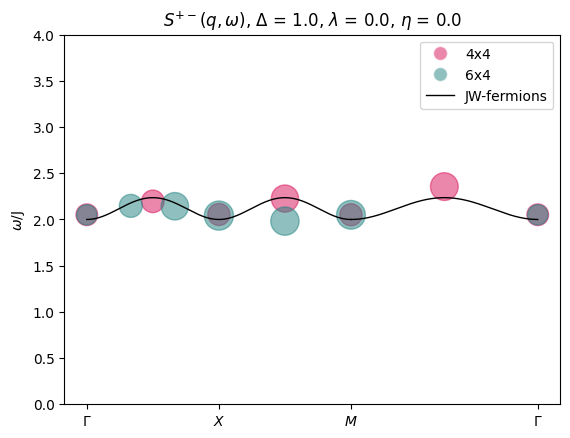

In [23]:
plot_all_for_var(dir='+-', delta=1., lamb=0., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.ylim([0., 4.])

No file for key: 18A
No file for key: 24A


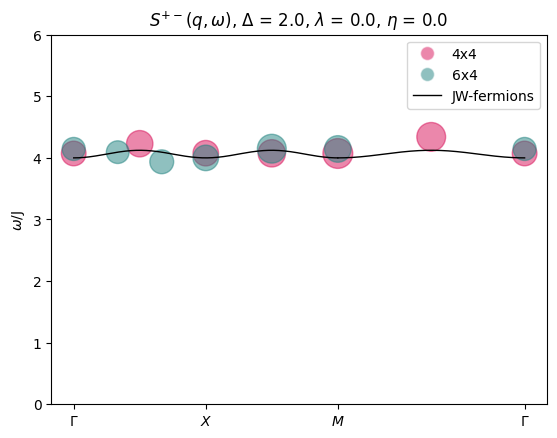

No file for key: 24A


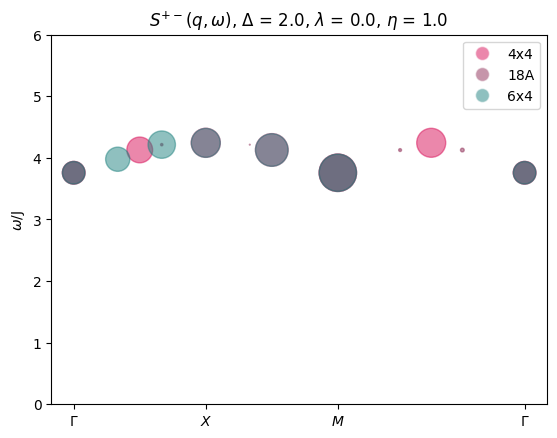

In [24]:
plot_all_for_var(delta=2., lamb=0., eta = 0., to_diameter=False, marker_size=900, alpha=.5)
plot_all_for_var(delta=2., lamb=0., to_diameter=False, marker_size=900, alpha=.5)

No file for key: 18A
No file for key: 24A


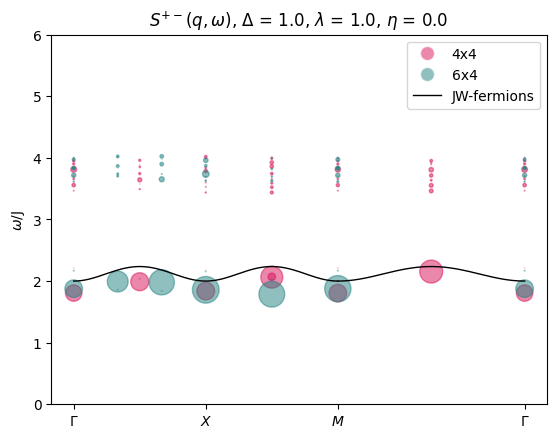

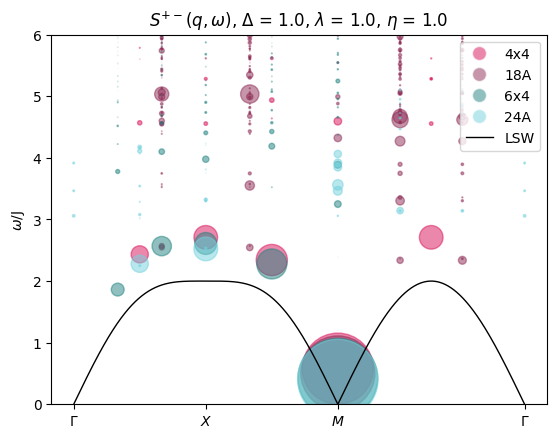

In [25]:
plot_all_for_var(delta=1., lamb=1., eta = 0., dir='+-', to_diameter=False, marker_size=900, alpha=.5)
plot_all_for_var(delta=1., lamb=1., to_diameter=False, marker_size=900, alpha=.5)

No file for key: 4x4
No file for key: 6x4
No file for key: 24A


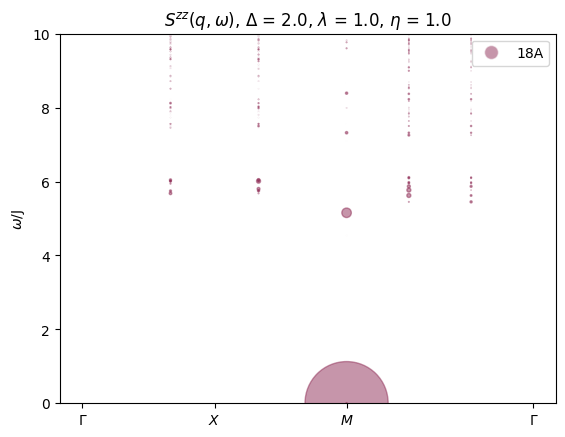

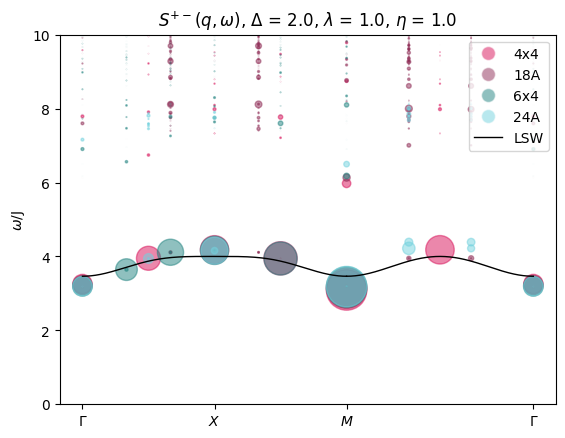

In [26]:
plot_all_for_var(delta=2., lamb=1., dir='zz', to_diameter=False, marker_size=900, alpha=.5, ylim=10)
plot_all_for_var(delta=2., lamb=1., dir='+-', to_diameter=False, marker_size=900, alpha=.5, ylim=10)

No file for key: 18A
No file for key: 24A
No file for key: 18A
No file for key: 24A


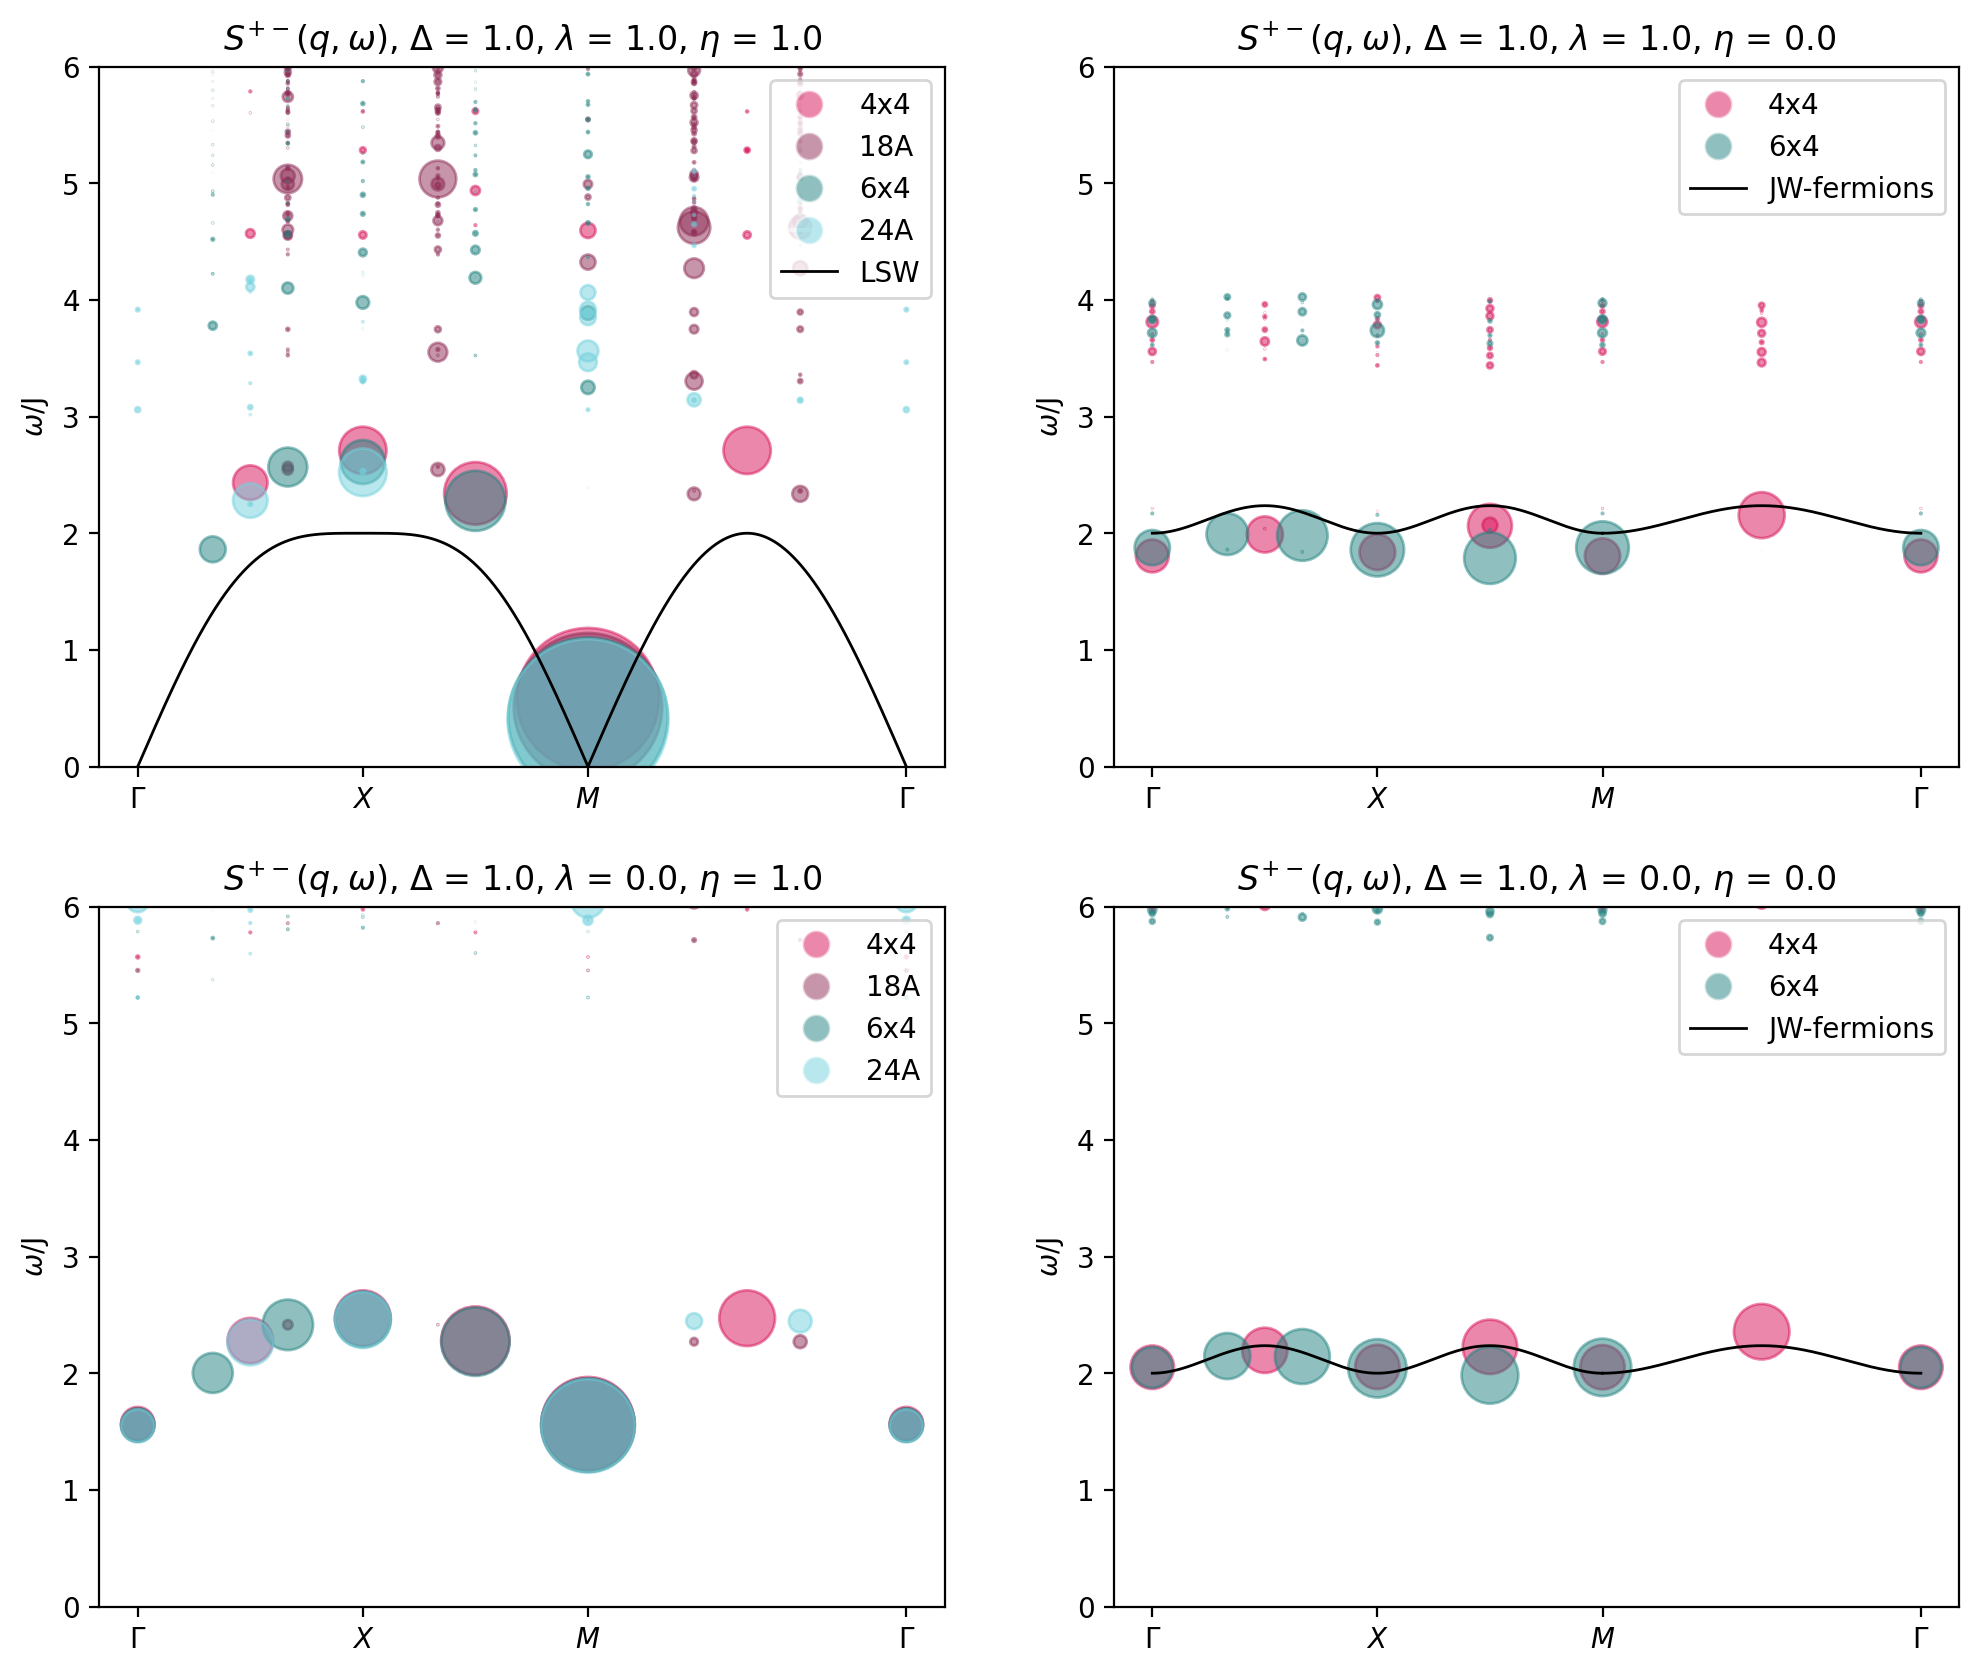

In [27]:
fig = plt.figure(figsize = (12, 10), dpi = 200)
plt.subplot(2, 2, 1)
plot_all_for_var(dir='+-', delta=1., lamb=1., eta = 1., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 2)
plot_all_for_var(dir='+-', delta=1., lamb=1., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 3)
plot_all_for_var(dir='+-', delta=1., lamb=0., eta = 1., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 4)
plot_all_for_var(dir='+-', delta=1., lamb=0., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.show()

No file for key: 24A
No file for key: 18A
No file for key: 24A
No file for key: 18A
No file for key: 24A


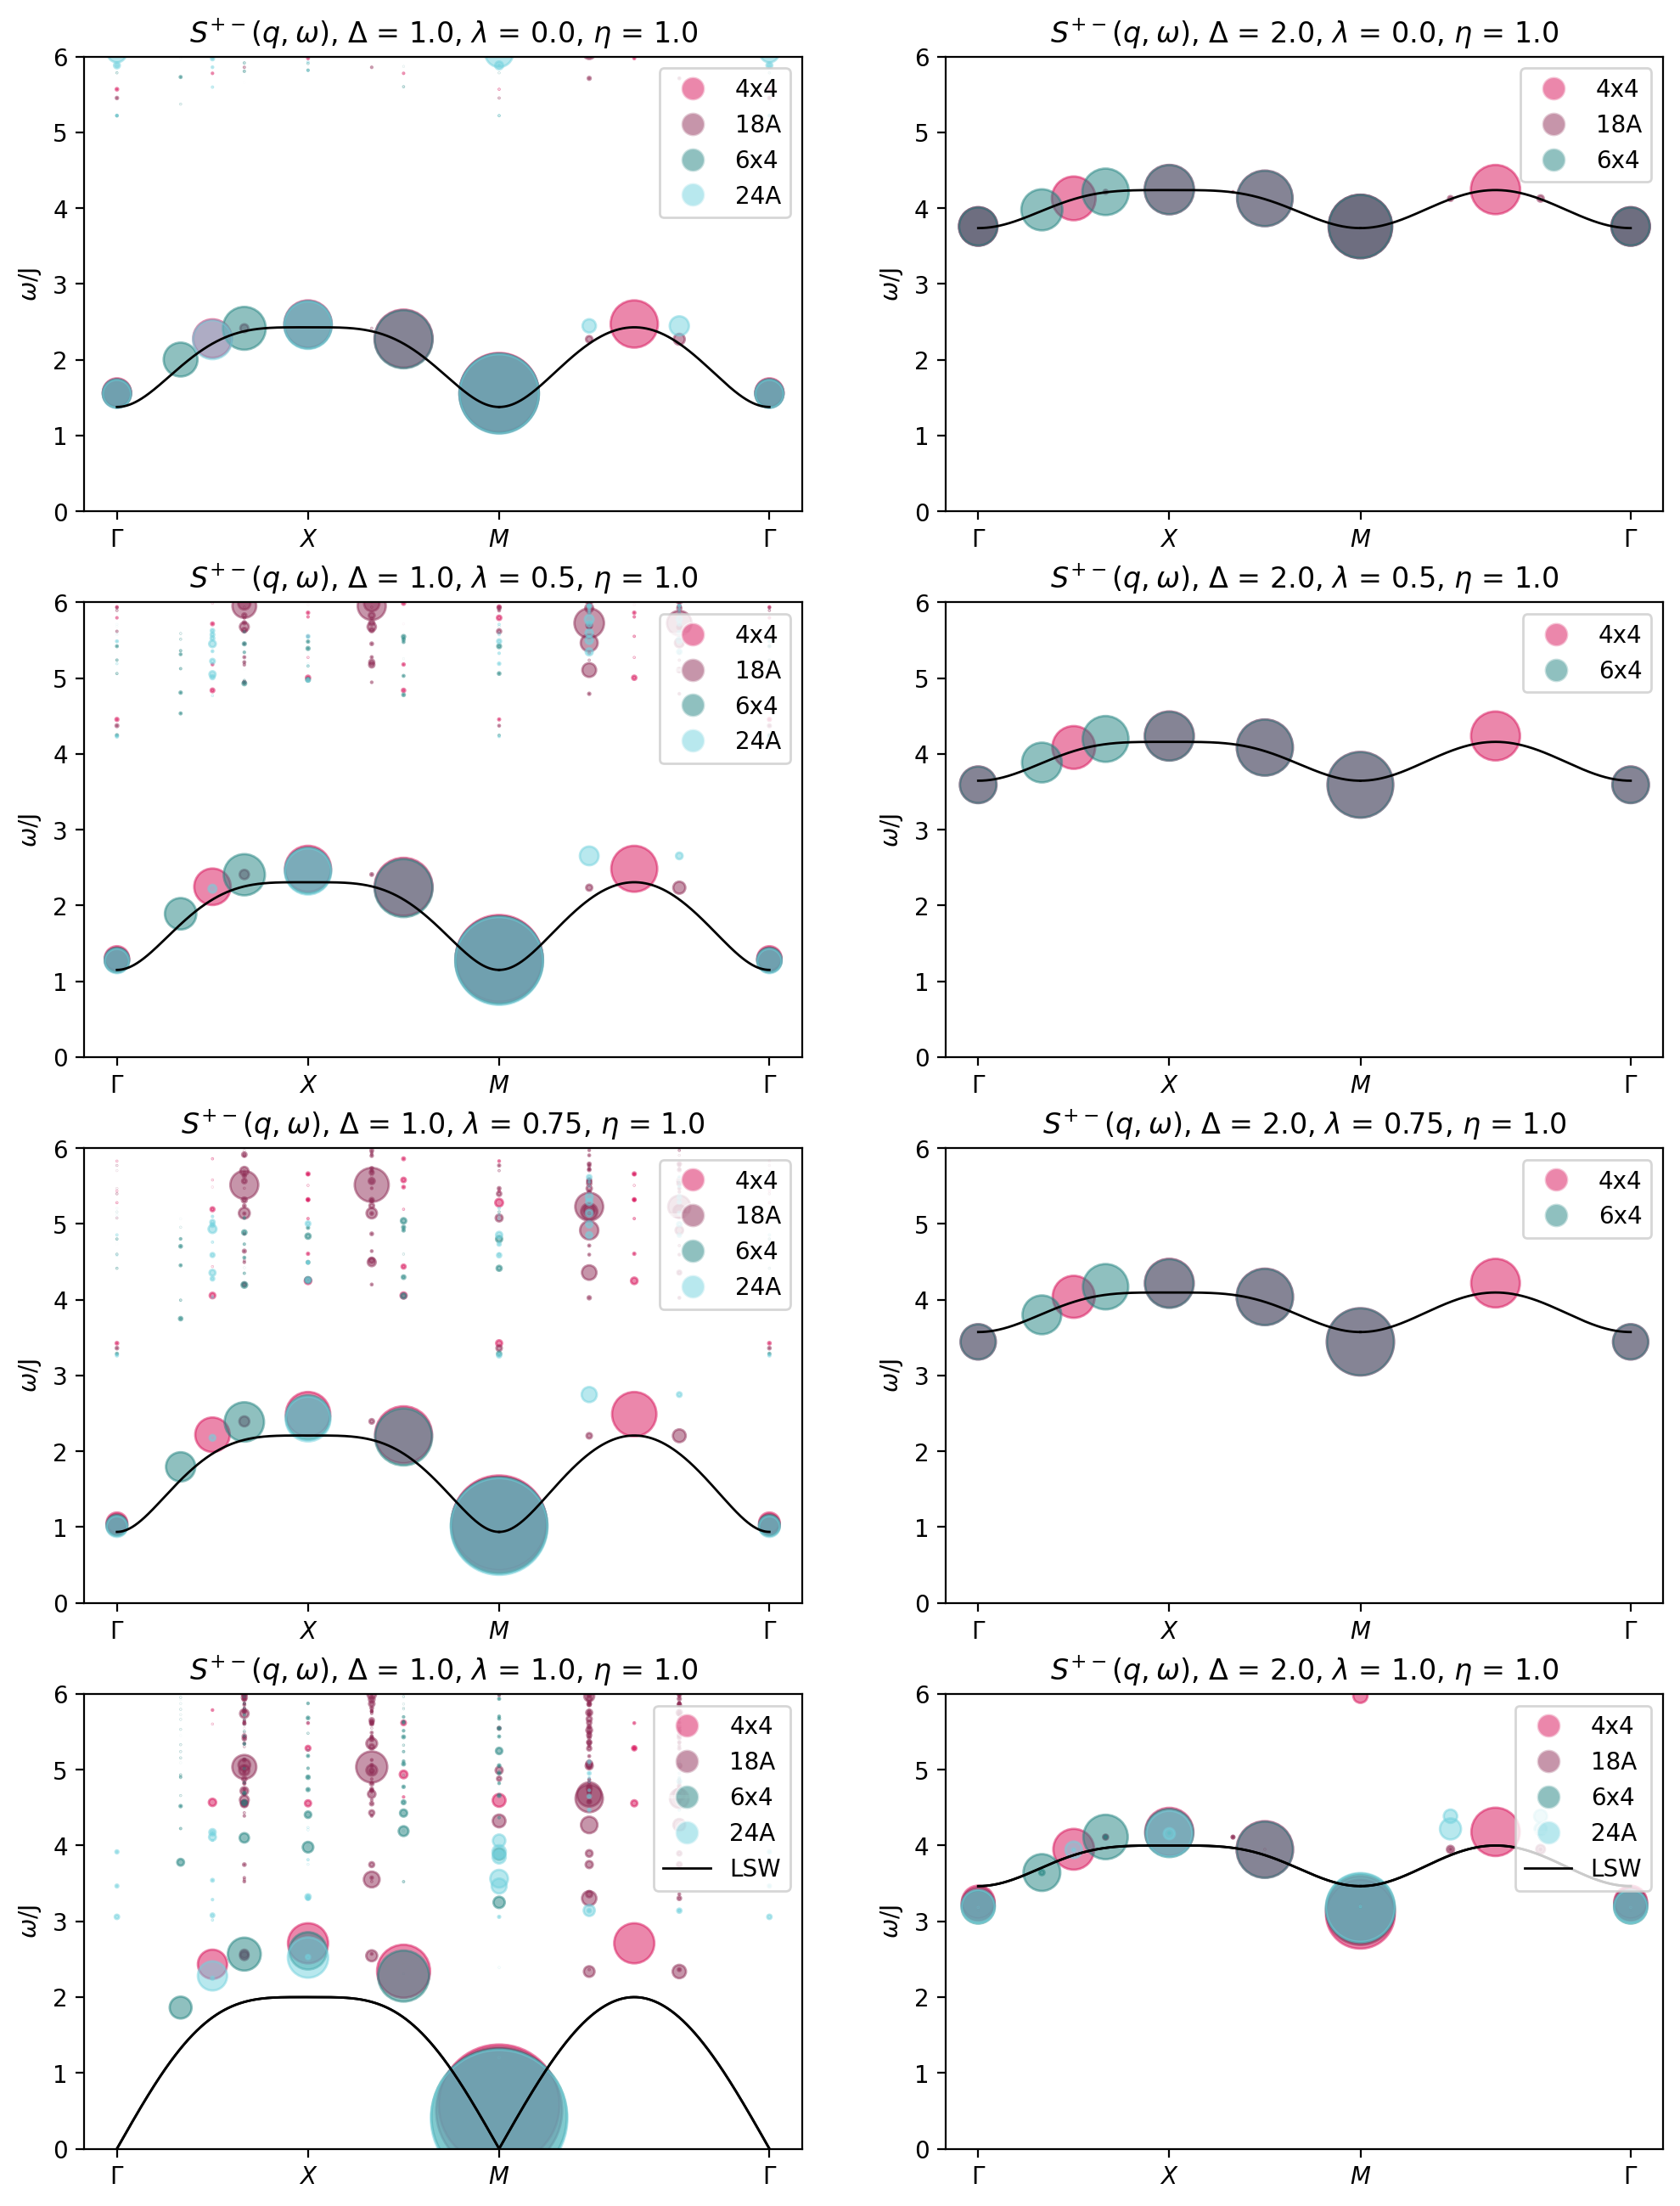

In [28]:
def find_function_lamb(delta = 1., lamb = 0., _alpha = 0.):
    x_range = np.arange( 0, 2.00001, 0.001 )

    kx = np.pi * np.clip(x_range, 0., 1.)
    ky = np.pi * (np.clip(x_range, 1., 2.)-1.)

    delta_k = (np.cos(kx) + np.cos(ky))/2.
    alpha = (1. - lamb) * delta * 4 * _alpha
    y = 2. * np.sqrt((delta+alpha)**2 - delta_k**2)

    plt.plot( x_range, y, 'black', lw = 1. )

    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k_range = np.linspace(1., 0., len(x_range), endpoint=True) * np.pi

    delta_k = (np.cos(k_range) + np.cos(k_range))/2.
    y = 2. * np.sqrt((delta+alpha)**2 - delta_k**2)

    plt.plot( x_range, y, 'black', lw = 1. )

    plot_all_for_var(dir='+-', delta=delta, lamb=lamb, eta = 1., to_diameter=False, marker_size=900, alpha=.5, show = False)

fig = plt.figure(figsize = (12, 16), dpi = 200)
plt.subplot(4, 2, 1)
find_function_lamb(1., 0., 0.053499624740691414) #0.03910101867787485
plt.subplot(4, 2, 2)
find_function_lamb(2., 0., 0.014884112830855965) #0.009758864997001914

plt.subplot(4, 2, 3)
find_function_lamb(1., 0.5, 0.0768335602074369) #0.03910101867787485
plt.subplot(4, 2, 4)
find_function_lamb(2., 0.5, 0.01987963769322372) #0.009758864997001914

plt.subplot(4, 2, 5)
find_function_lamb(1., 0.75, 0.10436913882490878) #0.03910101867787485
plt.subplot(4, 2, 6)
find_function_lamb(2., 0.75, 0.023793490171486048) #0.009758864997001914

plt.subplot(4, 2, 7)
find_function_lamb(1., 1., 0.49999912970124555) #0.03910101867787485
plt.subplot(4, 2, 8)
find_function_lamb(2., 1., 0.5168518123373316) #0.009758864997001914
plt.show()

No file for key: 24A


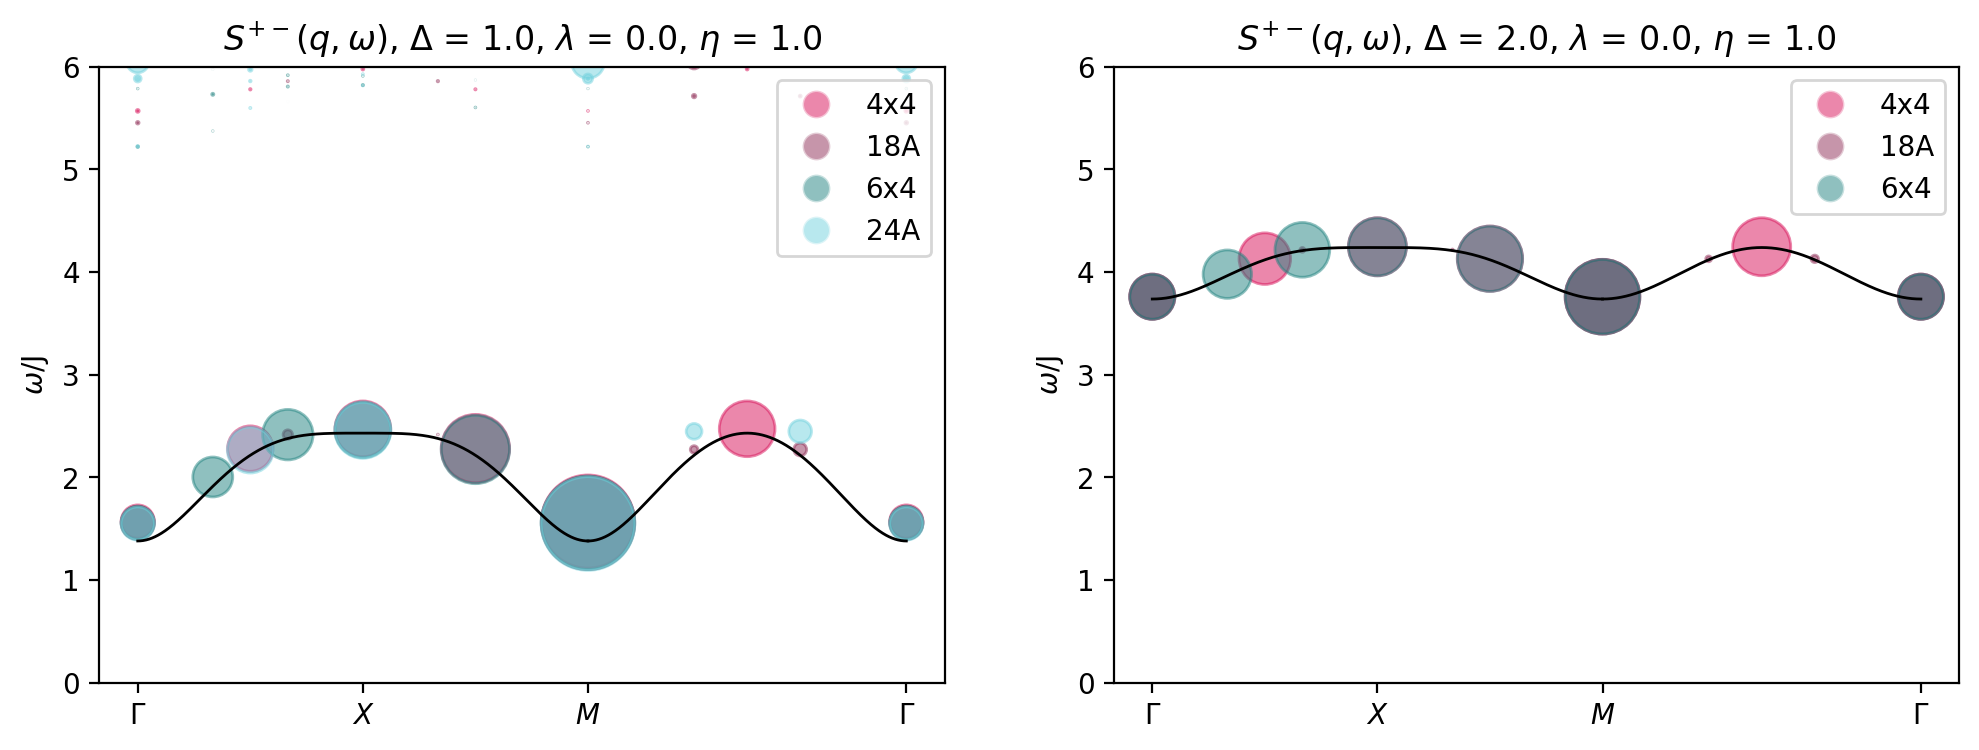

In [29]:
def find_function(delta = 1., alpha = 0.):
    x_range = np.arange( 0, 2.00001, 0.001 )

    kx = np.pi * np.clip(x_range, 0., 1.)
    ky = np.pi * (np.clip(x_range, 1., 2.)-1.)

    delta_k = (np.cos(kx) + np.cos(ky))/2.
    y = 2. * np.sqrt((delta+alpha)**2 - delta_k**2)

    plt.plot( x_range, y, 'black', lw = 1. )

    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k_range = np.linspace(1., 0., len(x_range), endpoint=True) * np.pi

    delta_k = (np.cos(k_range) + np.cos(k_range))/2.
    y = 2. * np.sqrt((delta+alpha)**2 - delta_k**2)

    plt.plot( x_range, y, 'black', lw = 1. )

    plot_all_for_var(dir='+-', delta=delta, lamb=0., eta = 1., to_diameter=False, marker_size=900, alpha=.5, show = False)

fig = plt.figure(figsize = (12, 4), dpi = 200)
plt.subplot(1, 2, 1)
find_function(1., 4*0.053673480448829004) #0.03910101867787485
plt.subplot(1, 2, 2)
find_function(2., 4*2*0.01483042339122892) #0.009758864997001914
plt.show()

No file for key: 24A
No file for key: 24A


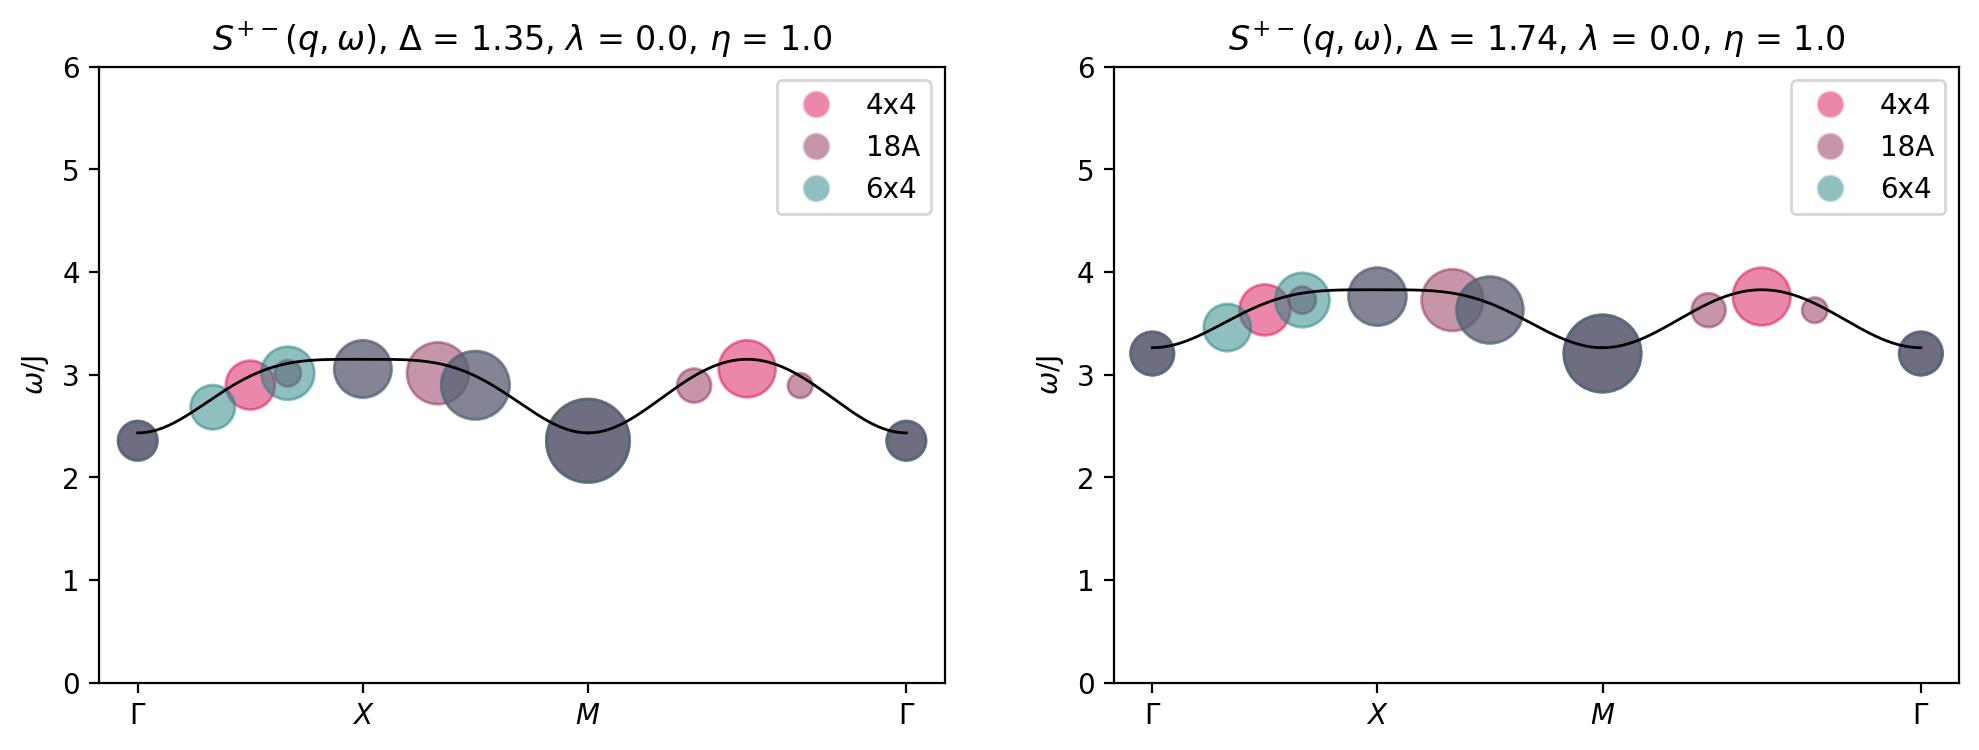

In [30]:
def find_function(delta = 1., alpha = 0.):
    x_range = np.arange( 0, 2.00001, 0.001 )

    kx = np.pi * np.clip(x_range, 0., 1.)
    ky = np.pi * (np.clip(x_range, 1., 2.)-1.)

    delta_k = (np.cos(kx) + np.cos(ky))/2.
    y = 2. * np.sqrt((delta+alpha)**2 - delta_k**2)

    plt.plot( x_range, y, 'black', lw = 1. )

    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k_range = np.linspace(1., 0., len(x_range), endpoint=True) * np.pi

    delta_k = (np.cos(k_range) + np.cos(k_range))/2.
    y = 2. * np.sqrt((delta+alpha)**2 - delta_k**2)

    plt.plot( x_range, y, 'black', lw = 1. )

    plot_all_for_var(dir='+-', delta=delta, lamb=0., eta = 1., to_diameter=False, marker_size=900, alpha=.5, show = False)

fig = plt.figure(figsize = (12, 4), dpi = 200)
plt.subplot(1, 2, 1)
find_function(1.35, 0.22431341515784045)
plt.subplot(1, 2, 2)
find_function(1.74, 0.17295773268934622)
plt.show()